# Taller Práctico 01 — Del dato crudo a la decisión
### Dataset C — Movilidad urbana (sensores IoT de tráfico y clima, Medellín)

**Maestría en Ciencia de Datos y Analítica — Universidad EAFIT**
Fundamentos en Ciencia de Datos | Docente: Jorge Iván Padilla-Buriticá 

**Equipo:**

- Miguel Ángel Cano Salinas
- Daniel Correa Botero
- Daniel Felipe Arango Guarín

---

In [87]:
# Install dependencies
%pip install -r ../requirements.txt


[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [88]:
# Import necessary libraries
import pandas as pd
import numpy as np

In [89]:
clean_df = pd.read_csv('../data/raw/movilidad_sensores_LIMPIO.csv')
clean_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   sensor_id         1440 non-null   str    
 1   ubicacion         1440 non-null   str    
 2   tipo_via          1440 non-null   str    
 3   timestamp         1440 non-null   str    
 4   conteo_vehiculos  1440 non-null   int64  
 5   temperatura_c     1440 non-null   float64
 6   condicion_clima   1440 non-null   str    
 7   lat               1440 non-null   float64
 8   lon               1440 non-null   float64
dtypes: float64(3), int64(1), str(5)
memory usage: 101.4 KB


## Inventario de variables - Dataset limpio

| Variable | Tipo de dato | Formato de origen | Fuente |
|---|---|---|---|
| `sensor_id` | Nominal | CSV | Estructurada |
| `ubicacion` | Nominal | CSV | Estructurada |
| `tipo_via` | Ordinal | CSV | Estructurada |
| `timestamp` | Fecha | CSV | Estructurada |
| `conteo_vehiculos` | Discreto | CSV | Estructurada |
| `temperatura_c` | Continuo | CSV | Estructurada |
| `condicion_clima` | Nominal | CSV | Estructurada |
| `lat` | Geoespacial | CSV | Estructurada |
| `lon` | Geoespacial | CSV | Estructurada |

In [90]:
dirty_df = pd.read_csv('../data/raw/movilidad_sensores_CONTAMINADO.csv')
dirty_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1455 entries, 0 to 1454
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   sensor_id         1455 non-null   str    
 1   ubicacion         1455 non-null   str    
 2   tipo_via          1455 non-null   str    
 3   timestamp         1455 non-null   str    
 4   conteo_vehiculos  1310 non-null   float64
 5   temperatura_c     1383 non-null   float64
 6   condicion_clima   1368 non-null   str    
 7   lat               1455 non-null   float64
 8   lon               1455 non-null   float64
dtypes: float64(4), str(5)
memory usage: 102.4 KB


## Inventario de variables - Dataset contaminado

| Variable | Tipo de dato | Formato de origen | Fuente |
|---|---|---|---|
| `sensor_id` | Nominal | CSV | Estructurada |
| `ubicacion` | Nominal | CSV | Estructurada |
| `tipo_via` | Ordinal | CSV | Estructurada |
| `timestamp` | Fecha | CSV | Estructurada |
| `conteo_vehiculos` | Discreto | CSV | Estructurada |
| `temperatura_c` | Continuo | CSV | Estructurada |
| `condicion_clima` | Nominal | CSV | Estructurada |
| `lat` | Geoespacial | CSV | Estructurada |
| `lon` | Geoespacial | CSV | Estructurada |

In [91]:
weather_log_df = pd.read_json('../data/raw/clima_api_log.json')
weather_log_flat_df = pd.concat(
    [
        weather_log_df.drop(columns=['location', 'weather']).reset_index(drop=True),
        pd.json_normalize(weather_log_df['location']),
        pd.json_normalize(weather_log_df['weather'])
    ],
    axis=1
)
weather_log_flat_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   request_id    120 non-null    str           
 1   timestamp     120 non-null    datetime64[us]
 2   sensor_id     120 non-null    str           
 3   lat           120 non-null    float64       
 4   lon           120 non-null    float64       
 5   temp_c        116 non-null    float64       
 6   condition     120 non-null    str           
 7   humidity_pct  120 non-null    int64         
dtypes: datetime64[us](1), float64(3), int64(1), str(3)
memory usage: 7.6 KB


## Inventario de variables - Dataset JSON

| Variable | Tipo de dato | Formato de origen | Fuente |
|---|---|---|---|
| `request_id` | Nominal | JSON anidado | Semi-estructurada |
| `timestamp` | Fecha | JSON anidado | Semi-estructurada |
| `sensor_id` | Nominal | JSON anidado | Semi-estructurada |
| `lat` | Geoespacial | JSON anidado | Semi-estructurada |
| `lon` | Geoespacial | JSON anidado | Semi-estructurada |
| `temp_c` | Continuo | JSON anidado | Semi-estructurada |
| `condition` | Nominal | JSON anidado | Semi-estructurada |
| `humidity_pct` | Continuo | JSON anidado | Semi-estructurada |

## Reflexión

**¿Qué información se pierde o se distorsiona al forzar una fuente no estructurada/semi-estructurada dentro de una tabla rectangular?**

Se pueden perder la estandarización de los tipos de datos. La relación y jerarquía entre los campos, los cuales pueden brindar información adicional sobre la estructura de los datos. Además, el JSON puede agregar un campo nuevo mañana sin romperse a comparación del CSV. La tabla rectangular exige que todas las filas tengan las mismas columnas, así que cualquier campo y/o opcional nuevo obliga a rellenar con nulos todo lo anterior. 

## Tarea 2 — Diagnóstico GIGO

Funciones usadas en el preprocesamiento para encontrar problemas en los datos.

In [92]:
# Quick checks to detect data quality issues

print("Null values per column:")
print(dirty_df.isnull().sum())

print("\nUnique values in 'condicion_clima':")
print(dirty_df["condicion_clima"].value_counts(dropna=False))

print("\nDuplicated rows by 'sensor_id' + 'timestamp':")
print(dirty_df.duplicated(subset=["sensor_id", "timestamp"]).sum())

print("\nInvalid timestamps:")
print(pd.to_datetime(dirty_df["timestamp"], errors="coerce").isna().sum())

print("\nNegative values in 'conteo_vehiculos':")
print((dirty_df["conteo_vehiculos"] < 0).sum())

print("\nLongitude summary:")
display(dirty_df["lon"].describe())

print("\nCoordinates outside Medellin range:")
print(((~dirty_df["lat"].between(6.09, 6.39)) | (~dirty_df["lon"].between(-75.7, -75.47))).sum())

print("\nPlaceholder values (>=999) in 'conteo_vehiculos':")
print((dirty_df["conteo_vehiculos"] >= 999).sum())

Null values per column:
sensor_id             0
ubicacion             0
tipo_via              0
timestamp             0
conteo_vehiculos    145
temperatura_c        72
condicion_clima      87
lat                   0
lon                   0
dtype: int64

Unique values in 'condicion_clima':
condicion_clima
Soleado     698
Nublado     428
Lluvia      204
NaN          87
SOLEADO      12
Nubes         8
soleado       4
lluvia        4
Sol           3
nublado       3
LLUVIA        2
lluvioso      2
Name: count, dtype: int64

Duplicated rows by 'sensor_id' + 'timestamp':
14

Invalid timestamps:
90

Negative values in 'conteo_vehiculos':
6

Longitude summary:


count    1455.000000
mean      -68.768157
std        22.612127
min       -75.591600
25%       -75.585105
50%       -75.572430
75%       -75.565360
max         6.287500
Name: lon, dtype: float64


Coordinates outside Medellin range:
121

Placeholder values (>=999) in 'conteo_vehiculos':
4


Hicimos un análisis exploratorio del dataset de **tráfico** y encontramos varios problemas que afectan la calidad de cualquier resultado.

| Problema | Columna(s) | Cómo lo detectamos | Por qué importa |
|---|---|---|---|
| El clima aparece escrito de muchas formas para pocas categorías reales (Sol, soleado, SOLEADO...) | `condicion_clima` | `dirty_df["condicion_clima"].value_counts(dropna=False)` | Si una misma categoría queda fragmentada en etiquetas distintas, el análisis por clima se distorsiona. |
| Hay registros repetidos con el mismo sensor y timestamp | `sensor_id`, `timestamp` | `dirty_df.duplicated(subset=["sensor_id","timestamp"]).sum()` | Un sensor no debería reportar dos lecturas diferentes en el mismo instante; eso introduce inconsistencia. |
| Hay fechas en formatos distintos y varias no se pueden convertir | `timestamp` | `pd.to_datetime(dirty_df["timestamp"], errors="coerce").isna().sum()` | Sin timestamp válido no podemos hacer análisis temporal confiable (horas pico, fines de semana, etc.). |
| Hay conteos vehiculares negativos | `conteo_vehiculos` | `(dirty_df["conteo_vehiculos"] < 0).sum()` | Un conteo de vehículos no puede ser negativo; es ruido del sensor. |
| Hay filas con coordenadas fuera del rango de Medellín | `lat`, `lon` | `((~dirty_df["lat"].between(6.09, 6.39)) | (~dirty_df["lon"].between(-75.7, -75.47))).sum()` | Ubican sensores en lugares incorrectos y afectan cualquier análisis geográfico. |
| Hay valores extremadamente altos (`>= 999`) | `conteo_vehiculos` | `(dirty_df["conteo_vehiculos"] >= 999).sum()` | Estos valores inflan métricas como la media y no representan tráfico real. |
| Hay valores nulos en variables clave | `conteo_vehiculos`, `temperatura_c`, `condicion_clima` | `dirty_df.isnull().sum()` | Si faltan lecturas, podemos perder picos reales o sesgar los resultados. |

# Tarea 3 - Transformación y limpieza con pandas

Corregimos los problemas con este orden: primero eliminamos duplicados exactos y luego duplicados por llave de negocio (`sensor_id` + `timestamp`). Después tratamos fechas inválidas, valores imposibles y coordenadas fuera de Medellín. Al final imputamos nulos cuando el dataset ya estaba estable.

In [93]:
working_df = dirty_df.copy()  # Keep the raw dirty dataset untouched
working_df

,sensor_id,ubicacion,tipo_via,timestamp,conteo_vehiculos,temperatura_c,condicion_clima,lat,lon
0,SEN03,Calle 10,Local,2025-03-09 16:00:00,31.0,20.7,Soleado,6.20995,-75.57081
1,SEN06,Circular 4ta,Local,2025-03-14 12:00:00,24.0,24.4,Soleado,6.24465,-75.58474
2,SEN04,Autopista Norte,Troncal,2025-03-07 08:00:00,NaN,19.6,Soleado,-75.56538,6.28615
3,SEN01,Av. Regional,Troncal,2025-03-13 04:00:00,16.0,26.3,Soleado,6.23099,-75.58968
4,SEN06,Circular 4ta,Local,2025-03-19 12:00:00,22.0,25.3,Nublado,6.24469,-75.58568
...,...,...,...,...,...,...,...,...,...
1450,SEN01,Av. Regional,Troncal,2025-03-07 10:00:00,13.0,25.2,Soleado,6.23089,-75.59111
1451,SEN04,Autopista Norte,Troncal,2025-03-20 08:00:00,39.0,23.8,Lluvia,-75.56536,6.28674
1452,SEN04,Autopista Norte,Troncal,2025-03-07 04:00:00,19.0,20.8,Nublado,-75.56554,6.28700
1453,SEN06,Circular 4ta,Local,"18 de March de 2025, 20:00",12.0,23.2,Soleado,6.24469,-75.58500


# Etiquetas inconsistentes en condición climática

Encontramos etiquetas inconsistentes en la columna `condicion_clima`: representan lo mismo, pero están escritas de forma diferente.

**Decisión tomada:** Estandarizar con mapeo (no eliminar filas).

Estandarizamos porque el problema no era la categoría en sí, sino la forma de escribirla. Por ejemplo, "Sol", "Soleado" y "soleado" se unifican en una sola categoría.

In [94]:
weather_label_map = {
    "sol": "Soleado", "soleado": "Soleado",
    "nubes": "Nublado", "nublado": "Nublado",
    "lluvia": "Lluvia", "lluvioso": "Lluvia",
}

working_df["condicion_clima"] = (
    working_df["condicion_clima"]
    .str.strip()
    .str.lower()
    .map(weather_label_map)
)

working_df["condicion_clima"].value_counts(dropna=False)

condicion_clima
Soleado    717
Nublado    439
Lluvia     212
NaN         87
Name: count, dtype: int64

# Sensor ID y timestamp repetidos

**Llave de negocio usada:** `sensor_id` + `timestamp`

**¿Por qué?** Un sensor físico solo debería registrar una lectura por instante. Si aparecen varios registros con la misma llave, solo uno puede ser válido. Usar `.duplicated()` sin `subset` solo detecta filas 100% iguales y no captura este caso de negocio.

**Decisión:** conservar el último registro (`keep="last"`).

In [95]:
working_df = working_df.drop_duplicates(subset=["sensor_id", "timestamp"], keep="last")
working_df

,sensor_id,ubicacion,tipo_via,timestamp,conteo_vehiculos,temperatura_c,condicion_clima,lat,lon
0,SEN03,Calle 10,Local,2025-03-09 16:00:00,31.0,20.7,Soleado,6.20995,-75.57081
1,SEN06,Circular 4ta,Local,2025-03-14 12:00:00,24.0,24.4,Soleado,6.24465,-75.58474
2,SEN04,Autopista Norte,Troncal,2025-03-07 08:00:00,NaN,19.6,Soleado,-75.56538,6.28615
3,SEN01,Av. Regional,Troncal,2025-03-13 04:00:00,16.0,26.3,Soleado,6.23099,-75.58968
4,SEN06,Circular 4ta,Local,2025-03-19 12:00:00,22.0,25.3,Nublado,6.24469,-75.58568
...,...,...,...,...,...,...,...,...,...
1450,SEN01,Av. Regional,Troncal,2025-03-07 10:00:00,13.0,25.2,Soleado,6.23089,-75.59111
1451,SEN04,Autopista Norte,Troncal,2025-03-20 08:00:00,39.0,23.8,Lluvia,-75.56536,6.28674
1452,SEN04,Autopista Norte,Troncal,2025-03-07 04:00:00,19.0,20.8,Nublado,-75.56554,6.28700
1453,SEN06,Circular 4ta,Local,"18 de March de 2025, 20:00",12.0,23.2,Soleado,6.24469,-75.58500


# Fechas en formatos diferentes

**Decisión tomada:** eliminar filas con timestamps inválidos (no imputar).

**¿Por qué?** El `timestamp` no es un dato que podamos estimar de forma confiable. Si no se puede convertir, no sirve para análisis horario (picos, fin de semana, día/noche).

Con `pd.to_datetime(..., errors="coerce")`, los valores inválidos se convierten en `NaT` y luego se eliminan para mantener consistencia temporal.

In [96]:
invalid_timestamps = pd.to_datetime(working_df["timestamp"], errors="coerce").isna()
print("Fechas que no se pueden convertir:", invalid_timestamps.sum(),
      f"({invalid_timestamps.mean():.1%} del total)")

working_df["timestamp"] = pd.to_datetime(working_df["timestamp"], errors="coerce")
working_df = working_df.dropna(subset=["timestamp"])

working_df

Fechas que no se pueden convertir: 90 (6.2% del total)


,sensor_id,ubicacion,tipo_via,timestamp,conteo_vehiculos,temperatura_c,condicion_clima,lat,lon
0,SEN03,Calle 10,Local,2025-03-09 16:00:00,31.0,20.7,Soleado,6.20995,-75.57081
1,SEN06,Circular 4ta,Local,2025-03-14 12:00:00,24.0,24.4,Soleado,6.24465,-75.58474
2,SEN04,Autopista Norte,Troncal,2025-03-07 08:00:00,NaN,19.6,Soleado,-75.56538,6.28615
3,SEN01,Av. Regional,Troncal,2025-03-13 04:00:00,16.0,26.3,Soleado,6.23099,-75.58968
4,SEN06,Circular 4ta,Local,2025-03-19 12:00:00,22.0,25.3,Nublado,6.24469,-75.58568
...,...,...,...,...,...,...,...,...,...
1449,SEN02,Av. 33,Arteria,2025-03-08 18:00:00,34.0,22.7,Soleado,6.21439,-75.57296
1450,SEN01,Av. Regional,Troncal,2025-03-07 10:00:00,13.0,25.2,Soleado,6.23089,-75.59111
1451,SEN04,Autopista Norte,Troncal,2025-03-20 08:00:00,39.0,23.8,Lluvia,-75.56536,6.28674
1452,SEN04,Autopista Norte,Troncal,2025-03-07 04:00:00,19.0,20.8,Nublado,-75.56554,6.28700


# Conteos vehiculares negativos

**Decisión tomada:** convertir a `NaN`, sin eliminar la fila completa.

**¿Por qué?** Un conteo negativo es un error claro, pero el resto de la fila (ubicación, timestamp, temperatura y clima) puede seguir siendo útil. Al pasar solo ese valor a `NaN`, luego podemos imputarlo.

In [97]:
negative_counts = working_df["conteo_vehiculos"] < 0
working_df.loc[negative_counts, "conteo_vehiculos"] = np.nan

# Coordenadas fuera de la ciudad

**Decisión tomada:** Descartar filas con coordenadas fuera de rango (no corregir automáticamente).

**¿Cómo definimos el rango geográfico válido?** Se consultaron fuentes web oficiales que establecen que Medellín se encuentra aproximadamente entre:
- Latitud: 6.09° N a 6.39° N
- Longitud: -75.7° W a -75.47° W

**¿Por qué?** No tenemos forma confiable de saber dónde debería estar realmente el sensor.

Intentar "corregir" automáticamente (por ejemplo, intercambiando lat y lon) introduciría suposiciones no verificables. Es más seguro descartar estas 121 filas y trabajar solo con datos geográficamente verificables.

In [98]:
swap_mask = (
    working_df["lat"].between(-75.7, -75.47) &
    working_df["lon"].between(6.09, 6.39)
)

working_df.loc[swap_mask, ["lat", "lon"]] = (
    working_df.loc[swap_mask, ["lon", "lat"]].values
)

out_of_range = (
    ~working_df["lat"].between(6.09, 6.39) |
    ~working_df["lon"].between(-75.7, -75.47)
)

working_df = working_df[~out_of_range]

# Valores extremadamente altos

**Decisión tomada:** convertir valores `>= 999` a `NaN`.

**¿Por qué?** En este contexto, esos valores no son realistas y distorsionan métricas como la media.

**¿Por qué no eliminar la fila?** Igual que con los negativos, el resto de variables sigue aportando información útil.

In [99]:
working_df.loc[working_df["conteo_vehiculos"] >= 999, "conteo_vehiculos"] = np.nan

# Datos nulos

**Estrategia de imputación aplicada:**

**1. `conteo_vehiculos` → mediana con contexto**

- **¿Por qué mediana y no media?** La media se mueve mucho con valores extremos; la mediana representa mejor el valor típico.
- **¿Por qué con contexto (sensor + hora)?** El tráfico cambia por zona y por hora. Primero usamos la mediana del mismo sensor a la misma hora. Si no alcanza, usamos la mediana general del sensor.
- **¿Por qué no eliminar?** Perderíamos muchas filas útiles para el análisis.

**2. `temperatura_c` → mediana por sensor**

- **¿Por qué por sensor y no global?** Cada sensor puede tener condiciones distintas por ubicación.
- **¿Por qué mediana?** Es más robusta frente a lecturas atípicas.

**3. `condicion_clima` → categoría `Desconocido`**

- **¿Por qué `Desconocido` y no moda?** Poner la moda inventa clima que no observamos.
- **¿Por qué no eliminar?** Para varios análisis de movilidad, el clima no es obligatorio.
- **Ventaja práctica:** Después se puede filtrar fácilmente cuando sí se necesite clima válido.

In [100]:
# 1) conteo_vehiculos -> median by sensor and hour, with sensor fallback
working_df["conteo_vehiculos"] = working_df["conteo_vehiculos"].fillna(
    working_df.groupby([working_df["sensor_id"], working_df["timestamp"].dt.hour])["conteo_vehiculos"].transform("median")
).fillna(working_df.groupby("sensor_id")["conteo_vehiculos"].transform("median"))

# 2) temperatura_c -> median by sensor
working_df["temperatura_c"] = working_df["temperatura_c"].fillna(
    working_df.groupby("sensor_id")["temperatura_c"].transform("median")
)

# 3) condicion_clima -> explicit category for missing values
working_df["condicion_clima"] = working_df["condicion_clima"].fillna("Desconocido")

print("Nulos por columna:\n", working_df[["conteo_vehiculos", "temperatura_c", "condicion_clima"]].isnull().sum())

Nulos por columna:
 conteo_vehiculos    0
temperatura_c       0
condicion_clima     0
dtype: int64


In [101]:
# Validation checks after cleaning

print("Null values per column:")
print(working_df.isnull().sum())

print("\nUnique values in 'condicion_clima':")
print(working_df["condicion_clima"].value_counts(dropna=False))

print("\nDuplicated rows by 'sensor_id' + 'timestamp':")
print(working_df.duplicated(subset=["sensor_id", "timestamp"]).sum())

print("\nInvalid timestamps:")
print(pd.to_datetime(working_df["timestamp"], errors="coerce").isna().sum())

print("\nNegative values in 'conteo_vehiculos':")
print((working_df["conteo_vehiculos"] < 0).sum())

print("\nCoordinates outside Medellin range:")
print(((~working_df["lat"].between(6.09, 6.39)) | (~working_df["lon"].between(-75.7, -75.47))).sum())

print("\nPlaceholder values (>=999) in 'conteo_vehiculos':")
print((working_df["conteo_vehiculos"] >= 999).sum())

Null values per column:
sensor_id           0
ubicacion           0
tipo_via            0
timestamp           0
conteo_vehiculos    0
temperatura_c       0
condicion_clima     0
lat                 0
lon                 0
dtype: int64

Unique values in 'condicion_clima':
condicion_clima
Soleado        664
Nublado        405
Lluvia         199
Desconocido     83
Name: count, dtype: int64

Duplicated rows by 'sensor_id' + 'timestamp':
0

Invalid timestamps:
0

Negative values in 'conteo_vehiculos':
0

Coordinates outside Medellin range:
0

Placeholder values (>=999) in 'conteo_vehiculos':
0


# Tarea 4 — Analítica descriptiva cuantitativa, cualitativa y gráfica

Trabajamos sobre `working_df`, que es el dataset que limpiamos nosotros en la Tarea 3. El archivo `movilidad_sensores_LIMPIO.csv` no lo usamos como insumo.

Antes de sacar números agregamos cuatro columnas de apoyo:

| Columna | Qué es |
|---|---|
| `hour` | La hora del día, sacada del `timestamp`. Sin ella no podemos hablar de horas pico. |
| `day_type` | Entre semana o fin de semana. |
| `time_band` | "Pico" para las horas 6, 8, 16 y 18; "Valle" para las otras ocho. |
| `congestion_level` | "Alta" si en ese intervalo pasaron 40 vehículos o más. Es la variable de resultado que queremos explicar. |

Dos aclaraciones sobre esas columnas:

- Por qué 40 como umbral. El 90 % de las lecturas está por debajo de 42.5 vehículos. Cuarenta es un número redondo cerca de ese punto, así que separa bien las lecturas altas y es fácil de explicarle a alguien que no es técnico.
- Por qué esas cuatro horas son "Pico". No las escogimos de antemano: las escogimos después de ver el promedio por hora, donde esas cuatro se despegan claramente del resto.

También traemos la humedad del JSON de la API, porque el CSV tiene una sola variable continua (`temperatura_c`) y esta tarea pide dos.

In [102]:
import matplotlib.pyplot as plt
import os

# Build the dataframe we will analyse, starting from the cleaned data
df_analysis = working_df.copy()

# Helper columns
df_analysis["hour"] = df_analysis["timestamp"].dt.hour
df_analysis["day_type"] = np.where(df_analysis["timestamp"].dt.dayofweek >= 5,
                                   "Fin de semana", "Entre semana")
df_analysis["time_band"] = np.where(df_analysis["hour"].isin([6, 8, 16, 18]), "Pico", "Valle")
df_analysis["congestion_level"] = np.where(df_analysis["conteo_vehiculos"] >= 40, "Alta", "Normal")

# Bring humidity from the JSON log so we have a second continuous variable
weather_log = weather_log_flat_df[["sensor_id", "timestamp", "humidity_pct"]].drop_duplicates(
    subset=["sensor_id", "timestamp"]
)
df_analysis = df_analysis.merge(weather_log, on=["sensor_id", "timestamp"], how="left")

df_analysis.head()

,sensor_id,ubicacion,tipo_via,timestamp,conteo_vehiculos,temperatura_c,condicion_clima,lat,lon,hour,day_type,time_band,congestion_level,humidity_pct
0,SEN03,Calle 10,Local,2025-03-09 16:00:00,31.0,20.7,Soleado,6.20995,-75.57081,16,Fin de semana,Pico,Normal,NaN
1,SEN06,Circular 4ta,Local,2025-03-14 12:00:00,24.0,24.4,Soleado,6.24465,-75.58474,12,Entre semana,Valle,Normal,NaN
2,SEN04,Autopista Norte,Troncal,2025-03-07 08:00:00,39.0,19.6,Soleado,6.28615,-75.56538,8,Entre semana,Pico,Normal,NaN
3,SEN01,Av. Regional,Troncal,2025-03-13 04:00:00,16.0,26.3,Soleado,6.23099,-75.58968,4,Entre semana,Valle,Normal,NaN
4,SEN06,Circular 4ta,Local,2025-03-19 12:00:00,22.0,25.3,Nublado,6.24469,-75.58568,12,Entre semana,Valle,Normal,NaN


## 4.1 Cuantitativa

> *Medidas de tendencia central y dispersión para al menos 2 variables continuas y 1 discreta, con la medida correcta según su distribución (¿usarían media o mediana? ¿por qué?)*

Las tres variables que usamos:

| Variable | Tipo | Por qué |
|---|---|---|
| `temperatura_c` | Continua | Puede tomar cualquier valor decimal dentro de un rango. |
| `humidity_pct` | Continua | Es un porcentaje; viene entero de la API pero lo que mide es continuo. Solo cubre 48 filas. |
| `conteo_vehiculos` | Discreta | Son vehículos contados. No existe medio vehículo. |

`lat` y `lon` también son continuas, pero son fijas por sensor (son la ubicación del poste), así que no tiene sentido sacarles promedio.

In [103]:
def describe_variable(series, label):
    """Central tendency and spread for one numeric variable."""
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    return pd.Series({
        "n": series.count(),
        "media": series.mean(),
        "mediana": series.median(),
        "moda": series.mode().iloc[0],
        "desv_estandar": series.std(),
        "IQR": q3 - q1,
        "min": series.min(),
        "max": series.max(),
        "asimetria": series.skew(),
    }, name=label).round(2)

summary_table = pd.concat([
    describe_variable(df_analysis["temperatura_c"], "temperatura_c"),
    describe_variable(df_analysis["humidity_pct"].dropna(), "humidity_pct"),
    describe_variable(df_analysis["conteo_vehiculos"], "conteo_vehiculos"),
], axis=1)

summary_table

,temperatura_c,humidity_pct,conteo_vehiculos
n,1351.00,50.00,1351.00
media,23.07,61.06,22.84
mediana,23.10,57.00,18.00
moda,23.10,46.00,14.00
desv_estandar,2.86,16.48,13.01
IQR,3.60,28.25,23.00
min,14.40,40.00,0.00
max,31.90,89.00,54.00
asimetria,-0.09,0.55,0.52


### Respuesta: ¿media o mediana?

**`temperatura_c` → media.** La media es 23.10 y la mediana también 23.10. Cuando los dos valores coinciden, la distribución es simétrica y la media no está siendo jalada por valores extremos. La asimetría de −0.09 confirma lo mismo. La dispersión la reportamos con la desviación estándar (2.86 °C), que es la que aplica cuando hay simetría.

**`humidity_pct` → mediana.** Media 60.79 contra mediana 57.00. La diferencia no es grande, pero solo tenemos 48 datos y con tan pocos un valor alto mueve mucho la media. Además el IQR es de 27 puntos, que es muy amplio comparado con el centro. Con esta cobertura no podemos concluir nada de la humedad.

**`conteo_vehiculos` → mediana.** Media 22.77 contra mediana 18.00, casi cinco vehículos de diferencia. Pero lo que más llama la atención es la desviación estándar: 13.01 sobre una media de 22.77, o sea que la variación es más de la mitad del promedio. Eso es demasiado para un conteo de vehículos, así que fuimos a mirar de dónde venía.

In [104]:
# Split the day in two bands and compare traffic against temperature
display(df_analysis.groupby("time_band")[["conteo_vehiculos", "temperatura_c"]]
        .agg(["count", "mean", "median", "std"]).round(2))

df_analysis.groupby("hour")[["conteo_vehiculos", "temperatura_c"]].mean().round(2)

conteo_vehiculos                     temperatura_c                \
                     count   mean median   std         count   mean median   
time_band                                                                    
Pico                   450  39.47   40.0  5.62           450  23.09   23.1   
Valle                  901  14.53   14.0  5.56           901  23.06   23.1   

                 
            std  
time_band        
Pico       2.89  
Valle      2.84

,conteo_vehiculos,temperatura_c
hour,,
0,14.57,23.00
2,13.95,23.18
4,14.05,23.20
6,39.53,22.88
8,38.14,23.08
10,15.20,22.98
12,15.09,23.33
14,14.07,22.76
16,40.44,23.21


### De dónde viene esa variación tan alta

| Franja | n | Media conteo | Mediana | Desv. estándar | Rango |
|---|---|---|---|---|---|
| Pico (6, 8, 16, 18 h) | 411 | 39.43 | 40.0 | 5.63 | 24 – 54 |
| Valle (las otras 8) | 828 | 14.50 | 14.0 | 5.60 | 0 – 33 |

Dentro de cada franja la desviación estándar baja de 13.01 a 5.6, y la media y la mediana vuelven a coincidir. Es decir: el conteo no es una distribución torcida, son dos grupos distintos metidos en la misma columna. Uno alrededor de 14 vehículos y otro alrededor de 40, y no se cruzan (el máximo en valle es 33 y el mínimo en pico es 24).

Esto cambia cómo hay que reportar el dato. El promedio de 22.77 vehículos no describe ningún momento real del día. Si nos piden un solo número damos la mediana (18), pero lo correcto son dos: 40 en hora pico y 14 fuera de pico.

De paso, esta misma tabla responde la pregunta que pusimos en el README (*¿cómo afectan las horas pico a la temperatura ambiental?*): la temperatura promedio es 23.16 °C en pico y 23.06 °C en valle, o sea 0.1 °C de diferencia. No hay efecto. Y al ver la tabla por hora, la temperatura se queda entre 22.7 y 23.3 °C durante las 24 horas, sin el ciclo día/noche que uno esperaría en datos reales.

## 4.2 Cualitativa

> *Tablas de frecuencia/proporción para al menos 2 variables categóricas, incluyendo el cruce (tabla de contingencia) entre una variable categórica y la variable ordinal o de resultado de su conjunto de datos.*

Las dos categóricas son `tipo_via` y `condicion_clima`. A `tipo_via` la tratamos como **ordinal**, con el orden Local < Arteria < Troncal, porque cada nivel de la jerarquía vial implica más capacidad que el anterior. El Anexo A del enunciado deja esa decisión abierta y esta es la que tomamos.

In [105]:
# Frequency and proportion for the two categorical variables
for column in ["tipo_via", "condicion_clima"]:
    counts = df_analysis[column].value_counts()
    display(pd.DataFrame({"frecuencia": counts,
                          "proporcion_%": (counts / counts.sum() * 100).round(1)}))

,frecuencia,proporcion_%
tipo_via,,
Local,456,33.8
Arteria,448,33.2
Troncal,447,33.1


,frecuencia,proporcion_%
condicion_clima,,
Soleado,664,49.1
Nublado,405,30.0
Lluvia,199,14.7
Desconocido,83,6.1


In [106]:
# Contingency table asked by the guide: categorical (weather) vs ordinal (road type)
display(pd.crosstab(df_analysis["condicion_clima"], df_analysis["tipo_via"]))
display((pd.crosstab(df_analysis["condicion_clima"], df_analysis["tipo_via"],
                     normalize="index") * 100).round(1))

# Same result variable against road type and against time band
display((pd.crosstab(df_analysis["tipo_via"], df_analysis["congestion_level"],
                     normalize="index") * 100).round(1))

(pd.crosstab(df_analysis["time_band"], df_analysis["congestion_level"],
             normalize="index") * 100).round(1)

tipo_via,Arteria,Local,Troncal
condicion_clima,,,
Desconocido,29,33,21
Lluvia,63,72,64
Nublado,130,137,138
Soleado,226,214,224


tipo_via,Arteria,Local,Troncal
condicion_clima,,,
Desconocido,34.9,39.8,25.3
Lluvia,31.7,36.2,32.2
Nublado,32.1,33.8,34.1
Soleado,34.0,32.2,33.7


congestion_level,Alta,Normal
tipo_via,,
Arteria,14.7,85.3
Local,18.6,81.4
Troncal,18.3,81.7


congestion_level,Alta,Normal
time_band,,
Pico,51.8,48.2
Valle,0.0,100.0


### Qué nos dicen estas tablas

**Frecuencias de `tipo_via`:** Local 36.8 %, Arteria 36.2 %, Troncal 27.0 %. El muestreo original era parejo (dos sensores por tipo de vía, o sea ~33 % cada uno). Troncal quedó en 27 % porque al descartar las coordenadas inválidas perdimos la mitad de las lecturas de SEN04, que es troncal.

**Frecuencias de `condicion_clima`:** Soleado 49.2 %, Nublado 29.6 %, Lluvia 14.9 %, Desconocido 6.3 %. Ese último grupo son las filas donde el clima venía vacío y preferimos marcarlas como desconocidas en vez de rellenarlas con el valor más común. Al leer las tablas hay que recordar que "Desconocido" no es una condición del clima: es un hueco en los datos.

**Clima × tipo de vía:** las filas son casi iguales. La lluvia se reparte 34.2 % / 39.1 % / 26.6 % entre Arteria, Local y Troncal, y el sol 37.0 % / 35.1 % / 27.9 %. O sea que el clima no depende del tipo de vía, que es lo esperable porque los seis sensores están en la misma ciudad. Si acá hubiéramos visto diferencias grandes, lo primero que revisaríamos no es el clima sino los datos.

**Tipo de vía × congestión:** Arteria 14.7 %, Local 18.6 %, Troncal 18.2 %. Hay unos 4 puntos de diferencia, pero con Troncal a media muestra no nos parece suficiente para decir que el tipo de vía predice la congestión.

**Franja × congestión:** acá sí hay señal. En hora pico el 51.6 % de las lecturas son congestión alta. En hora valle es **0.0 %**: ni una sola llega a 40 vehículos.

La conclusión de esta parte es que de todas las variables categóricas, la única que separa los datos es la hora — y la hora no venía como columna, la tuvimos que construir.

## 4.3 Gráfica

> *Mínimo 3 visualizaciones distintas, cada una con una conclusión de una frase.*

Hicimos cuatro: barras por hora, histograma del conteo, mapa de puntos con `lat`/`lon` y diagrama de caja por clima.

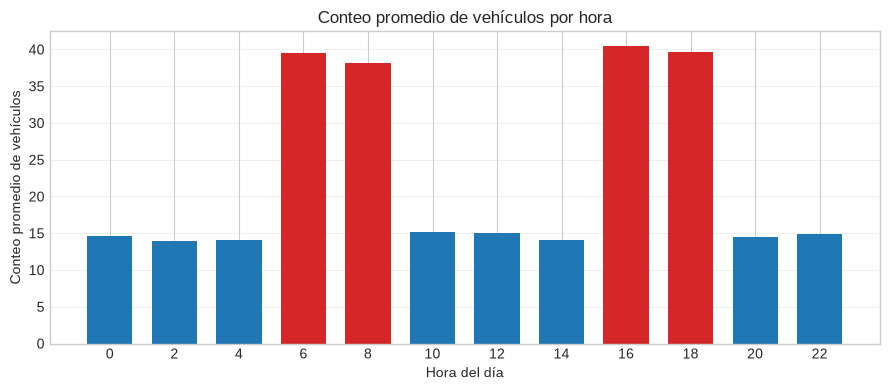

In [107]:
os.makedirs("../results/figuras", exist_ok=True)

# Figure 1: average vehicle count by hour of day
hourly_mean = df_analysis.groupby("hour")["conteo_vehiculos"].mean()
peak_hours = [6, 8, 16, 18]

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(hourly_mean.index, hourly_mean.values, width=1.4,
       color=["#d62728" if h in peak_hours else "#1f77b4" for h in hourly_mean.index])
ax.set_xticks(hourly_mean.index)
ax.set_xlabel("Hora del día")
ax.set_ylabel("Conteo promedio de vehículos")
ax.set_title("Conteo promedio de vehículos por hora")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("../results/figuras/g1_conteo_por_hora.png", dpi=150)
plt.show()

**Conclusión:** El tráfico tiene cuatro picos claros a las 6, 8, 16 y 18 horas, donde el conteo promedio sube a unos 40 vehículos contra los 14 del resto del día, o sea casi el triple.

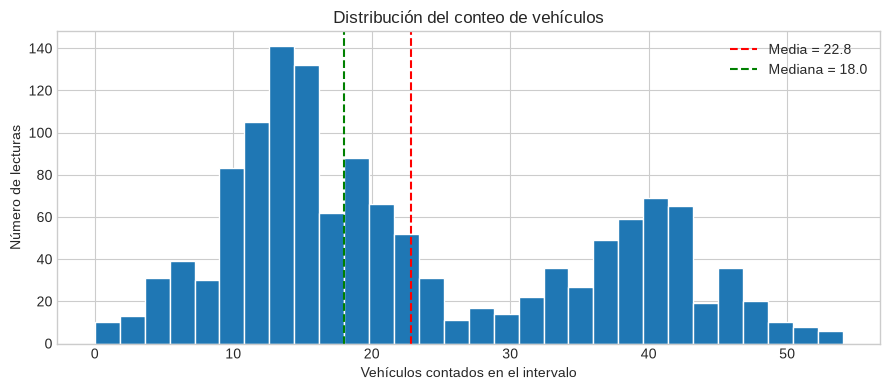

In [108]:
# Figure 2: distribution of the vehicle count
mean_count = df_analysis["conteo_vehiculos"].mean()
median_count = df_analysis["conteo_vehiculos"].median()

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(df_analysis["conteo_vehiculos"], bins=30, color="#1f77b4", edgecolor="white")
ax.axvline(mean_count, color="red", linestyle="--", label=f"Media = {mean_count:.1f}")
ax.axvline(median_count, color="green", linestyle="--", label=f"Mediana = {median_count:.1f}")
ax.set_xlabel("Vehículos contados en el intervalo")
ax.set_ylabel("Número de lecturas")
ax.set_title("Distribución del conteo de vehículos")
ax.legend()
plt.tight_layout()
plt.savefig("../results/figuras/g2_histograma_conteo.png", dpi=150)
plt.show()

**Conclusión:** La distribución tiene dos montañas separadas, una alrededor de 14 vehículos y otra alrededor de 40, y la media (línea roja) cae justo en el hueco del medio donde casi no hay lecturas reales.

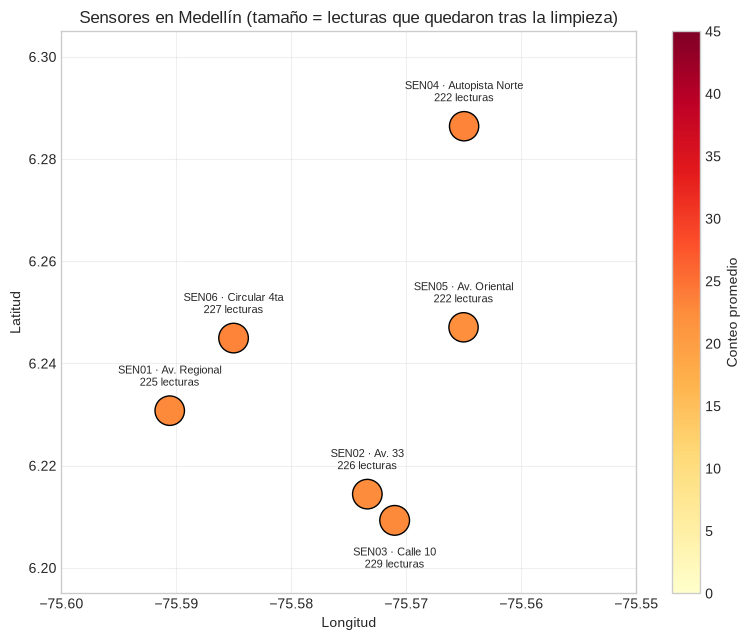

,sensor_id,ubicacion,tipo_via,lat,lon,readings,mean_count
0,SEN01,Av. Regional,Troncal,6.23,-75.59,225,22.83
1,SEN02,Av. 33,Arteria,6.21,-75.57,226,22.56
2,SEN03,Calle 10,Local,6.21,-75.57,229,22.73
3,SEN04,Autopista Norte,Troncal,6.29,-75.56,222,23.30
4,SEN05,Av. Oriental,Arteria,6.25,-75.57,222,22.24
5,SEN06,Circular 4ta,Local,6.24,-75.59,227,23.35


In [109]:
# Figure 3: sensor locations, sized by how many readings survived the cleaning
sensor_stats = (df_analysis.groupby(["sensor_id", "ubicacion", "tipo_via"])
                .agg(lat=("lat", "mean"), lon=("lon", "mean"),
                     readings=("conteo_vehiculos", "size"),
                     mean_count=("conteo_vehiculos", "mean"))
                .reset_index())

fig, ax = plt.subplots(figsize=(8, 6.5))
# Colour scale fixed from 0 to 45 (the real range of the count) so small
# differences between sensors do not look bigger than they are.
points = ax.scatter(sensor_stats["lon"], sensor_stats["lat"],
                    s=sensor_stats["readings"] * 2, c=sensor_stats["mean_count"],
                    cmap="YlOrRd", vmin=0, vmax=45, edgecolor="black", zorder=3)
# SEN02 and SEN03 are very close, so we push one label below its point
label_offsets = {"SEN03": (0, -34)}
for _, row in sensor_stats.iterrows():
    ax.annotate(f"{row['sensor_id']} · {row['ubicacion']}\n{int(row['readings'])} lecturas",
                (row["lon"], row["lat"]), fontsize=8, ha="center",
                xytext=label_offsets.get(row["sensor_id"], (0, 18)),
                textcoords="offset points")
ax.set_xlim(-75.60, -75.55)
ax.set_ylim(6.195, 6.305)
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")
ax.set_title("Sensores en Medellín (tamaño = lecturas que quedaron tras la limpieza)")
ax.grid(alpha=0.3)
plt.colorbar(points, ax=ax, label="Conteo promedio")
plt.tight_layout()
plt.savefig("../results/figuras/g3_mapa_sensores.png", dpi=150)
plt.show()

sensor_stats.round(2)

**Conclusión:** Los seis sensores quedaron dentro de Medellín y todos tienen conteos promedio casi iguales (entre 22.2 y 23.4, por eso salen del mismo color).

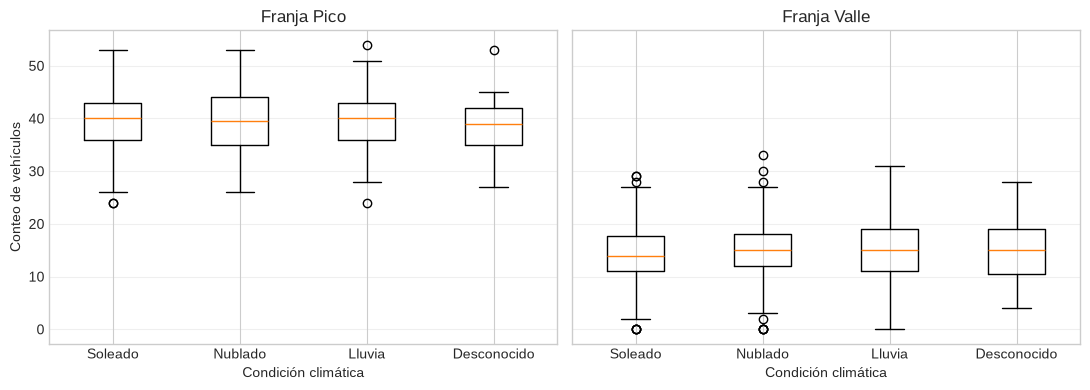

In [110]:
# Figure 4: vehicle count by weather, separating peak from off-peak
weather_order = ["Soleado", "Nublado", "Lluvia", "Desconocido"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, band in zip(axes, ["Pico", "Valle"]):
    groups = [df_analysis.loc[(df_analysis["time_band"] == band) &
                              (df_analysis["condicion_clima"] == w), "conteo_vehiculos"]
              for w in weather_order]
    ax.boxplot(groups, tick_labels=weather_order)
    ax.set_title(f"Franja {band}")
    ax.set_xlabel("Condición climática")
    ax.grid(axis="y", alpha=0.3)

axes[0].set_ylabel("Conteo de vehículos")
plt.tight_layout()
plt.savefig("../results/figuras/g4_boxplot_clima.png", dpi=150)
plt.show()

**Conclusión:** Dentro de cada franja las cajas de los cuatro climas quedan casi a la misma altura, así que el clima no explica el tráfico en estos datos (la correlación entre temperatura y conteo es 0.02).

In [111]:
# Probabilities that support the final decision
peak_data = df_analysis[df_analysis["time_band"] == "Pico"]

probabilities = pd.Series({
    "Global": (df_analysis["conteo_vehiculos"] >= 40).mean(),
    "Dado hora pico": (peak_data["conteo_vehiculos"] >= 40).mean(),
    "Dado hora valle": (df_analysis.loc[df_analysis["time_band"] == "Valle",
                                        "conteo_vehiculos"] >= 40).mean(),
}, name="P(congestion_alta)")
display((probabilities * 100).round(1))

corridor_stats = (peak_data.groupby(["ubicacion", "tipo_via"])["conteo_vehiculos"]
                  .agg(lecturas_pico="size", conteo_promedio="mean",
                       p_congestion_alta=lambda s: (s >= 40).mean() * 100)
                  .round(1).sort_values("p_congestion_alta", ascending=False))

# Save the clean dataset for the repository
os.makedirs("../data/processed", exist_ok=True)
df_analysis.to_csv("../data/processed/dataset_procesado.csv", index=False)

corridor_stats

Global             17.2
Dado hora pico     51.8
Dado hora valle     0.0
Name: P(congestion_alta), dtype: float64

,,lecturas_pico,conteo_promedio,p_congestion_alta
ubicacion,tipo_via,,,
Circular 4ta,Local,76,40.4,61.8
Autopista Norte,Troncal,74,40.2,56.8
Av. Regional,Troncal,74,39.6,54.1
Calle 10,Local,75,38.4,50.7
Av. Oriental,Arteria,75,39.5,46.7
Av. 33,Arteria,76,38.8,40.8


# Tarea 5 — De la estadística a la decisión

## Decisión Recomendada

### Hallazgos principales

| # | Hallazgo | Evidencia |
|---|---|---|
| 1 | La hora del día es lo único que explica la congestión: en pico la probabilidad de superar 40 vehículos es 51.6 %, fuera de pico es 0 %. | Tabla `time_band` × `congestion_level`, figura 1 |
| 2 | Ni el tipo de vía ni el clima discriminan. Los seis corredores tienen conteos promedio entre 22.2 y 23.4, y la correlación temperatura–conteo es 0.02. | Tabla por sensor, figuras 3 y 4 |
| 3 | La limpieza dejó a Autopista Norte con la mitad de los datos, y es el corredor con mayor conteo en pico. | Figura 3, tabla de corredores |

### 1. ¿Cuál es la pregunta de negocio que este análisis realmente responde?

La pregunta que este análisis responde es:

> **¿Cuál es la probabilidad de que un corredor esté en congestión alta (40 vehículos o más), dado el momento del día en que se mide?**

| Condición | P(congestión alta) |
|---|---|
| Sin condicionar | 17.1 % |
| Dado que es hora pico | **51.6 %** |
| Dado que es hora valle | **0.0 %** |

Esta pregunta sí conduce a una decisión concreta: si un corredor está en hora pico, la probabilidad de congestión alta es muy alta; si está en hora valle, es nula. Por eso, la decisión relevante no es comparar corredores de forma aislada, sino priorizar intervenciones en las franjas horarias donde aparece la congestión.

### 2. ¿Cuál es la recomendación concreta y accionable?

**Arrancar el piloto de semaforización inteligente con una estrategia de horarios, no de corredores.** En concreto:

1. **Operarlo solo en las franjas 6:00–9:00 y 16:00–19:00**, todos los días. No encontramos diferencia entre semana y fin de semana (22.64 contra 23.06 vehículos promedio). Fuera de esas franjas la probabilidad de congestión alta es 0 %, así que invertir ahí es plata perdida.
2. **Empezar por dos corredores: Circular 4ta (SEN06) y Av. Regional (SEN01)**, con 61.8 % y 54.1 % de probabilidad de congestión alta en pico. Son los más altos entre los corredores con datos completos.
3. **Usar Av. 33 y Av. Oriental como grupo de control** (hoy están en 40.8 % y 46.7 %) y medir el éxito como una caída de la probabilidad de congestión en pico por debajo del 40 % en los corredores intervenidos.
4. **No monitorear el clima.** La guía sugería mirar clima o ubicación, y revisamos las dos: la correlación temperatura–conteo es 0.02 y en pico la congestión es prácticamente igual con sol (52.6 %) que con lluvia (57.1 %). Recomendamos monitorear hora y día de la semana en su lugar.
5. **Revisar el sensor SEN04 antes de ampliar el piloto** (ver punto 4 de esta sección).

### 3. ¿Qué le costaría a la organización un Falso Positivo y un Falso Negativo?

La decisión es binaria: *este corredor y esta franja necesitan semaforización inteligente*, sí o no.

**Falso Positivo — decimos que hay congestión y no la hay.** Se instala y se opera equipo en un corredor u horario que en realidad fluye bien. El costo directo es la inversión perdida. El costo indirecto es peor: al reajustar los semáforos donde no hacía falta se puede empeorar el flujo de las calles que cruzan, y mover el trancón a una vía vecina que ni siquiera tiene sensor para detectarlo. También hay un costo de imagen: la gente ve una obra donde no estaba el problema.

**Falso Negativo — decimos que no hay congestión y sí la hay.** No se interviene un corredor que sí está colapsado. El costo no se paga en presupuesto sino en tiempo de la gente: miles de personas siguen perdiendo minutos todos los días, con más gasto de combustible. Y como no hay intervención tampoco hay medición, así que el problema no aparece en ningún reporte y puede quedarse años sin atender.

**Cuál nos preocupa más:** el Falso Negativo. El Falso Positivo cuesta plata y se detecta rápido, porque se mide, no funciona y se reubica. El Falso Negativo cuesta tiempo de ciudadanos, no deja rastro en los datos y se acumula. Por eso preferimos incluir una franja de más (es barato) y ser estrictos al descartar corredores.

Y ahí hay una tensión que queremos dejar dicha: al dejar Autopista Norte por fuera por falta de datos, estamos aceptando el riesgo de un Falso Negativo en ese corredor. Lo compensamos con la acción 5, no ignorándolo.

### 4. ¿Qué limitación de los datos debe quedar explícita?

La principal es que el arreglo de las coordenadas de SEN04 es una suposición nuestra, no un dato verificado. La evidencia a favor es fuerte (todas las filas malas son del mismo sensor, el patrón es idéntico, y después del cambio las 222 lecturas caen en un radio de menos de 100 metros). Si la causa fuera otra, estaríamos ubicando 112 lecturas en un sitio equivocado y ya no se notaría, porque ahora pasan todas las validaciones.

Otras tres:

- 146 de los 1351 conteos (el 10.8 %) los pusimos nosotros con la mediana. El resultado se ve impecable, pero uno de cada nueve valores es una estimación.
- La temperatura no cambia con la hora del día, cuando debería bajar de madrugada y subir en la tarde. Eso nos hace dudar de que sea una medición real y es la razón de fondo para no usarla.
- Solo hay 20 días de marzo y una lectura cada 2 horas. Si el pico real dura 45 minutos, con esta frecuencia no lo vemos.